**Making a RL exploration agent visualization using Pygame**


In [ ]:
# This is a simple RL exploration agent on 2D grids using pygame
# rules for agents
# there is a mesh of obstacles and an agent need to cover all the coordinates of the mesh without vising same 
# coordinates agin
# if an agent visit an unique node then get +1.0 points
# if it visit a same node get -0.5 points
# and if it touches/breaking with walls then gets -1.0 points

# the task of the exploration RL agent is to cover all the mesh unvisited coordinates in a less number of time t

# mesh color (unvisited) white
# agent color balck
# if an agent visit new coordinates, mesh coordinate turns into green
# if it revisit a visited coordinate then color turns into red

# in this we'll also calculate how much time t does the agent takes to complete/visit entire mesh
# how many unique coordinates does the agent visit
# how many old coordinates does the agent visit

# also plot some interactive visualization

In [6]:
import pygame
import random
import pandas as pd


# configurations
GRID_SIZE = 20 
CELL_SIZE = 30
WIDTH = HEIGHT = GRID_SIZE * CELL_SIZE
FPS = 30 # speed controlling factor

WHITE = (255, 255, 255)
BLACK = (0, 0, 0)
GREEN = (0, 200, 0)
RED = (200, 0, 0)
GRAY = (120, 120, 120)

# agent rewards
REWARD_NEW = 1.0
REWARD_REPEAT = -0.5
REWARD_WALL = -1.0


# 
pygame.init()
screen = pygame.display.set_mode((WIDTH, HEIGHT))
pygame.display.set_caption("RL Exploration Visualization")
clock = pygame.time.Clock()

# grid state
visited = {}
maze = set()

# generating maze with random obsticles having grid size
for _ in range(int(GRID_SIZE * GRID_SIZE * 0.2)):
    maze.add((random.randint(0, GRID_SIZE - 1),
              random.randint(0, GRID_SIZE - 1)))


# agent initial position
agent_pos = [0, 0]
maze.discard((0, 0))

visited[(0, 0)] = "green" # if agent visit new coordinate, coordinate will be green colored

# agent stats
time_step = 0 # time taking by agent to explore
unique_visits = 1 # unique visiting by agent
revisits = 0 # no of revisint coordinate by agent
total_reward = 0 # total accumilated reward by agent

log_data = [] # storing all stats data

ACTIONS = [(0, 1), (0, -1), (1, 0), (-1, 0)] # agent can move up, down, left, right

running = True
while running:
    clock.tick(FPS)
    time_step += 1

    for event in pygame.event.get():
        if event.type == pygame.QUIT:
            running = False

    # agent exploration action
    dx, dy = random.choice(ACTIONS)
    new_x = agent_pos[0] + dx
    new_y = agent_pos[1] + dy

    reward = 0

    if 0 <= new_x < GRID_SIZE and 0 <= new_y < GRID_SIZE and (new_x, new_y) not in maze:
        agent_pos = [new_x, new_y]

        if (new_x, new_y) not in visited:
            visited[(new_x, new_y)] = "green" # if agent visit new coordinate -> green
            reward = REWARD_NEW
            unique_visits += 1
        else:
            visited[(new_x, new_y)] = "red" # if agent visit same coordinate -> red
            reward = REWARD_REPEAT
            revisits += 1
    else:
        reward = REWARD_WALL

    total_reward += reward

    # features of log data table
    log_data.append({
        "time_step": time_step,
        "unique_cells_visited": unique_visits,
        "revisits": revisits,
        "reward": reward,
        "total_reward": total_reward
    })

    
    # pygame window
    screen.fill(WHITE)

    # maze coordinates
    for (x, y) in maze:
        pygame.draw.rect(screen, GRAY,
                         (x * CELL_SIZE, y * CELL_SIZE, CELL_SIZE, CELL_SIZE))

    # visited cells
    for (x, y), color in visited.items():
        if color == "green":
            pygame.draw.rect(screen, GREEN,
                             (x * CELL_SIZE, y * CELL_SIZE, CELL_SIZE, CELL_SIZE))
        else:
            pygame.draw.rect(screen, RED,
                             (x * CELL_SIZE, y * CELL_SIZE, CELL_SIZE, CELL_SIZE))

    # agent
    pygame.draw.rect(screen, BLACK,
                     (agent_pos[0] * CELL_SIZE, agent_pos[1] * CELL_SIZE,
                      CELL_SIZE, CELL_SIZE))

    pygame.display.flip()

    # stop if all reachable cells explored
    if unique_visits >= (GRID_SIZE * GRID_SIZE - len(maze)):
        running = False

pygame.quit()

# save data table
df = pd.DataFrame(log_data)
df.to_csv("exploration_log.csv", index=False)

print("Exploration completed!")
print(f"Time steps: {time_step}")
print(f"Unique cells visited: {unique_visits}")
print(f"Revisits: {revisits}")
print("Data saved to rl_exploration_log.csv")


Exploration completed!
Time steps: 9774
Unique cells visited: 324
Revisits: 7474
Data saved to rl_exploration_log.csv


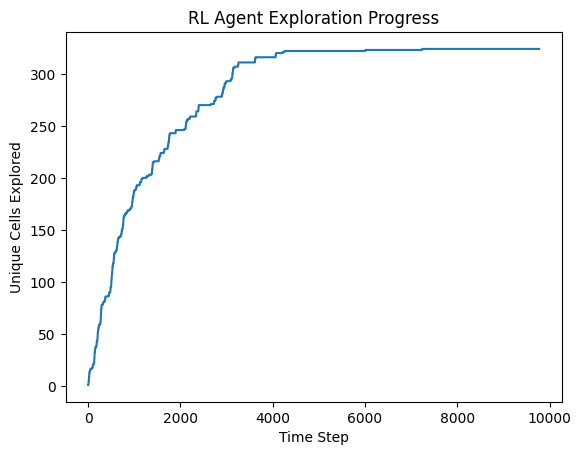

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("exploration_log.csv")

plt.plot(df["time_step"], df["unique_cells_visited"])
plt.xlabel("Time Step")
plt.ylabel("Unique Cells Explored")
plt.title("RL Agent Exploration Progress")
plt.show()

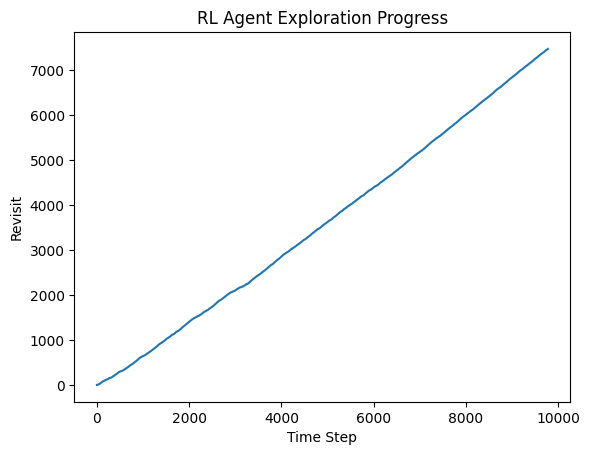

In [11]:
plt.plot(df["time_step"], df["revisits"])
plt.xlabel("Time Step")
plt.ylabel("Revisit")
plt.title("RL Agent Exploration Progress")
plt.show()

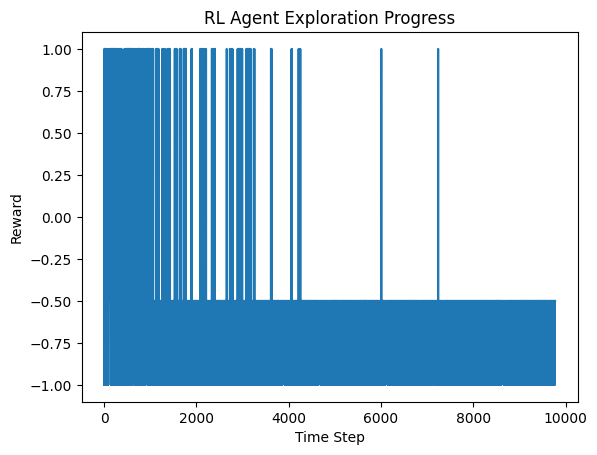

In [13]:
plt.plot(df["time_step"], df["reward"])
plt.xlabel("Time Step")
plt.ylabel("Reward")
plt.title("RL Agent Exploration Progress")
plt.show()

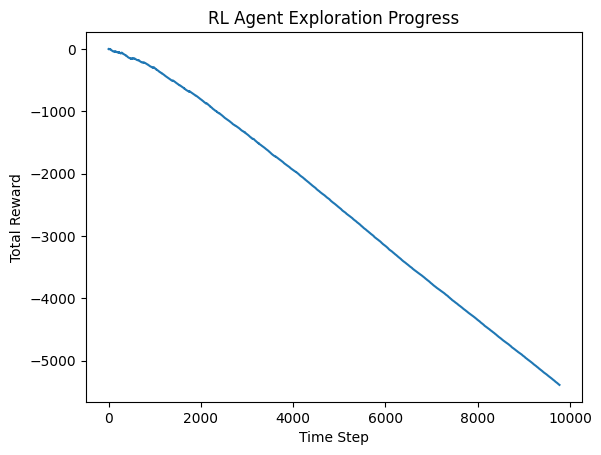

In [14]:
plt.plot(df["time_step"], df["total_reward"])
plt.xlabel("Time Step")
plt.ylabel("Total Reward")
plt.title("RL Agent Exploration Progress")
plt.show()